### DQN
+ Q学習とNNの融合
+ 経験再生: NN用のバッチデータを自己相関が低減するようにバッファに貯めて、そこからランダムに取り出す
+ ターゲットネットワークの導入

Open AI Gim

In [22]:
import gymnasium as gym

env = gym.make('CartPole-v0')

/Users/inoueshinichi/Desktop/MyGithub/Book_ZeroDeepLearning4/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


In [23]:
observation, info = env.reset(seed=42)
print(observation) # 初期観測(部分状態) (カートの位置, カートの速度, 棒の角度, 棒の角速度)

action_space = env.action_space
print(action_space) # 行動の次元数


[ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Discrete(2)


Open AI Gymは状態を観測とする. 部分マルコフ決定過程だと思う。$観測O \in 状態S$

In [24]:
action = 0 # 0: カートを左に移動, 1: カートを右に移動
next_observation, reward, terminated, truncated,info = env.step(action)
print(next_observation)
print(reward)
print(terminated)
print(truncated)
print(info)

[ 0.02727336 -0.20172954  0.03625453  0.32351476]
1.0
False
False
{}


https://gymnasium.farama.org/api/env/

+ step() - Updates an environment with actions returning the next agent observation, the reward for taking that actions, if the environment has terminated or truncated due to the latest action and information from the environment about the step, i.e. metrics, debug info.
+ reset() - Resets the environment to an initial state, required before calling step. Returns the first agent observation for an episode and information, i.e. metrics, debug info.
+ render() - Renders the environments to help visualise what the agent see, examples modes are “human”, “rgb_array”, “ansi” for text.
+ close() - Closes the environment, important when external software is used, i.e. pygame for rendering, databases

+ action_space - The Space object corresponding to valid actions, all valid actions should be contained within the space.
+ observation_space - The Space object corresponding to valid observations, all valid observations should be contained within the space.
+ spec - An environment spec that contains the information used to initialize the environment from gymnasium.make()
+ metadata - The metadata of the environment, e.g. {“render_modes”: [“rgb_array”, “human”], “render_fps”: 30}. For Jax or Torch, this can be indicated to users with “jax”=True or “torch”=True.
+ np_random - The random number generator for the environment. This is automatically assigned during super().reset(seed=seed) and when assessing np_random.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
%matplotlib inline
from gymnasium.wrappers import RecordVideo

Epi: 49, Step: 19


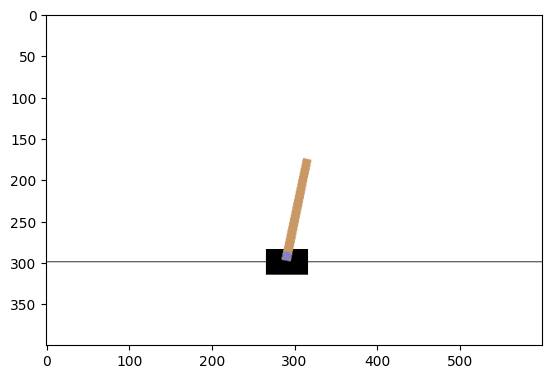

In [ ]:
episodes = 50
env = gym.make("CartPole-v1", render_mode="rgb_array")
observation, info = env.reset(seed=42)

# すべてのエピソードを保存
# env = RecordVideo(env, video_folder="./videos", episode_trigger=lambda e: True)

# 最後のエピソードのみを保存
env = RecordVideo(env, video_folder="./videos", episode_trigger=lambda e: e == episodes - 1)

for epi in range(episodes):
    observation, info = env.reset()
    done = False
    img = plt.imshow(env.render()) # 最初のフレーム

    step = 1
    while not done:
        # 画像を更新
        img.set_data(env.render())
        display.display(plt.gcf())
        display.clear_output(wait=True)
        
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        step += 1

    print(f"Epi: {epi}, Step: {step}")
        
env.close()

経験再生の実装

In [43]:
from collections import deque
import random
import numpy as np

class ReplayBuffer:
    def __init__(self, buffer_size, batch_size):
        self.buffer = deque(maxlen=buffer_size)
        self.batch_size = batch_size

    def add(self, obs, action, reward, next_obs, terminated, truncated):
        data = (obs, action, reward, next_obs, terminated, truncated)
        self.buffer.append(data)

    def __len__(self):
        return len(self.buffer)

    def get_batch(self):
        data = random.sample(self.buffer, self.batch_size)

        obs = np.stack([x[0] for x in data])
        action = np.array([x[1] for x in data])
        reward = np.array([x[2] for x in data])
        next_obs = np.stack([x[3] for x in data])
        terminated = np.array([x[4] for x in data]).astype(np.int32)
        truncated = np.array([x[5] for x in data]).astype(np.int32)
        return obs, action, reward, next_obs, terminated, truncated


Epi: 49, Step: 13


NameError: name 'reply_buffer' is not defined

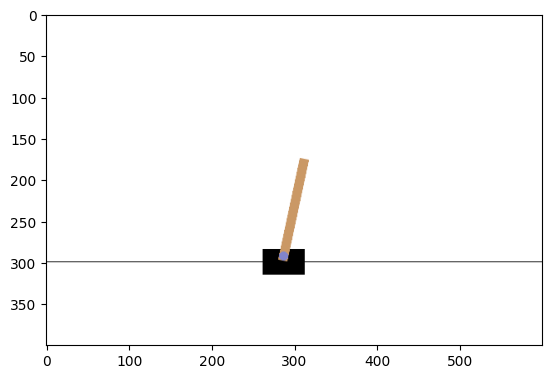

In [ ]:
episodes = 50
env = gym.make("CartPole-v1", render_mode="rgb_array")
observation, info = env.reset(seed=42)

# 経験再生
replay_buffer = ReplayBuffer(buffer_size=10000, batch_size=32)

# すべてのエピソードを保存
# env = RecordVideo(env, video_folder="./videos", episode_trigger=lambda e: True)

# 最後のエピソードのみを保存
env = RecordVideo(env, video_folder="./videos", episode_trigger=lambda e: e == episodes - 1)

for epi in range(episodes):
    obs, info = env.reset()
    done = False
    img = plt.imshow(env.render()) # 最初のフレーム

    step = 1
    while not done:
        # 画像を更新
        img.set_data(env.render())
        display.display(plt.gcf())
        display.clear_output(wait=True)
        
        action = env.action_space.sample()
        next_obs, reward, terminated, truncated, info = env.step(action)

        # 経験を蓄積
        replay_buffer.add(obs, action, reward, next_obs, terminated, truncated) 

        # 状態遷移
        obs = next_obs

        done = terminated or truncated
        step += 1

    print(f"Epi: {epi}, Step: {step}")
        
env.close()


In [47]:
obs, action, reward, next_obs, terminated, truncated = replay_buffer.get_batch()

print('--- shape ---')
print(obs.shape)
print(action.shape)
print(reward.shape)
print(terminated.shape)
print(truncated.shape)

print('--- value ---')
print(obs[:3, :])
print(action[:3])
print(reward[:3])
print(terminated[:3])
print(truncated[:3])

--- shape ---
(32, 4)
(32,)
(32,)
(32,)
(32,)
--- value ---
[[ 0.10785136  0.82174927 -0.09560727 -1.2357349 ]
 [ 0.05893083  0.9923384  -0.08714543 -1.4578105 ]
 [-0.03280419  0.23798907 -0.03612188 -0.3670467 ]]
[1 1 0]
[1. 1. 1.]
[0 0 0]
[0 0 0]


ターゲットネットワーク
+ 教師あり学習は正解ラベルが不変
+ Q学習は正解ラベル(TDターゲット $R_{t} + \gamma max_{a} Q(S_{t+1}, a)$)がQ関数が更新されると変動
+ ターゲットネットワークは、TDターゲットを固定するテクニック
+ Q学習ネットワークと同じ重みパラメータを持ち、定期的に更新される同一ネットワークを使って, TDターゲットを計算(固定する)
+ ターゲットネットワークは定期的に重みパラメータをQ学習ネットワークと同期する

Q学習ネットワーク
+ 更新式 $Q(S_{t},A_{t}) \leftarrow Q(S_{t},A_{t}) + \alpha \{ (R_{t} + \gamma max_{a} Q(S_{t+1},A_{t})) - Q(S_{t},A_{t}) \}$
+ 更新式をニューラルネットワークで表現する. 入力: $Q_{t},A_{t}$, 出力: $R_{t} + \gamma max_{a} Q(S_{t+1},A_{t})$

In [78]:
import torch

# CPUではなくMacのGPU(MPS)を使う設定
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [79]:
import torch.nn as nn
import torch.nn.functional as F


class QNet(nn.Module):
    def __init__(self, obs_size: int = 4, action_size: int = 2):
        super().__init__()
        # obs_size: [カートの位置, カートの速度, 棒の角度, 棒の角速度]
        hidden_size = 128
        self.l1 = nn.Linear(in_features=obs_size, out_features=hidden_size) # 中間サイズ
        self.l2 = nn.Linear(in_features=hidden_size, out_features=hidden_size)
        self.l3 = nn.Linear(in_features=hidden_size, out_features=action_size)

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = F.relu(self.l2(x))
        x = self.l3(x)
        return x

In [119]:
import torch.optim as optim

class DQNAgent:
    def __init__(self):
        self.gamma = 0.98
        self.lr = 0.0005
        self.epsilon = 0.1
        self.buffer_size = 10000
        self.batch_size = 32
        self.obs_size = 4    # 観測(=状態) [カートの位置, カートの速度, 棒の角度, 棒の角速度]
        self.action_size = 2 # 0: カートが左に動く, 1: カートが右に動く

        self.replay_buffer = ReplayBuffer(self.buffer_size, self.batch_size)
        self.qnet = QNet(obs_size=self.obs_size, action_size=self.action_size) 
        self.qnet_target = QNet(obs_size=self.obs_size, action_size=self.action_size)

        # Q学習ネットワークのみ学習
        self.optimizer = optim.Adam(self.qnet.parameters(), lr=self.lr)

    def sync_qnet(self):
        # pytorchで同期をとる方法(重みパラメータをコピー)
        self.qnet_target.load_state_dict(self.qnet.state_dict())

    def get_action(self, obs):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)
        else:
            obs = obs.unsqueeze(0) # (B,4)
            # print(f"obs.size(): {obs.size()}")
            qs = self.qnet(obs) # (B,4) -> (B,128) -> (B,128) -> (B,2)
            return torch.argmax(qs.detach().cpu(), dim=1).item()

    def update(self, obs, action, reward, next_obs, terminated, truncated):
        # print(f"def update@ obs: {obs}")
        # print(f"def update@ type(obs): {type(obs)}")

        # 経験蓄積
        self.replay_buffer.add(obs, action, reward, next_obs, terminated, truncated)
        if len(self.replay_buffer) < self.batch_size:
            return float('inf')
        
        # numpyを返す
        obs, action, reward, next_obs, terminated, truncated = self.replay_buffer.get_batch()

        # numpy -> torch
        obs = torch.from_numpy(obs)
        action = torch.from_numpy(action)
        reward = torch.from_numpy(reward)
        next_obs = torch.from_numpy(next_obs)
        # terminated = torch.from_numpy(terminated)
        # truncated = torch.from_numpy(truncated)

        # obs: (B=32,4)
        # action: (B=32,)
        # reward: (B=32,)
        # next_obs: (B=32,4)
        # terminated: (B=32,)
        # truncated: (B=32,)

        # print(f"obs.dtype: {obs.dtype}")
        # print(f"next_obs.dtype: {next_obs.dtype}")
        
        # Q学習ネットワークの順方向計算
        qs = self.qnet(obs) # No.1 (B=32,2)
        q = qs[torch.arange(self.batch_size), action] # No.2 (B=32,2) -> (B=32,) 
        # print(f"q: {q}")
        # print(f"type(q): {type(q)}")
        # print(f"q.dtype: {q.dtype}")
        """
        qs             action.          q
        [[0.1, 0.3],   [0,1,0,0,...,1]. [0.1, 0.6, 0.2, 0.9, ..., 0.3]
         [0.5, 0.6],
         [0.2, 0.8],
         [0.9, 0.5],
         ...
         [0.7, 0.3]]
        """

        # ターゲットネットワークで最大行動価値関数maxQを算出
        next_qs = self.qnet_target(next_obs).detach() # No.3
        # print(f"next_qs: {next_qs}")
        # print(f"type(next_qs): {type(next_qs)}")
        # print(f"next_qs.dtype: {next_qs.dtype}")
        next_q = torch.max(next_qs, dim=1)[0] # 次の状態における最大行動価値Q
        # print(f"next_q: {next_q}")
        # print(f"type(next_q): {type(next_q)}")
        # print(f"next_q.dtype: {next_q.dtype}")

        # エピソードが終了したか
        if isinstance(terminated, np.ndarray) and isinstance(truncated, np.ndarray):
            done = terminated.any() or truncated.any()
        else:
            done = terminated or truncated

        # TDターゲット
        target = reward + (1 - done) * self.gamma * next_q
        target = target.to(torch.float32)
        # print(f"target.dtype: {target.dtype}")

        # Q学習ネットワークの出力とTDターゲットで損失計算
        loss = F.mse_loss(target, q)

        # パラメータ更新
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

Epi: 299, Step: 18


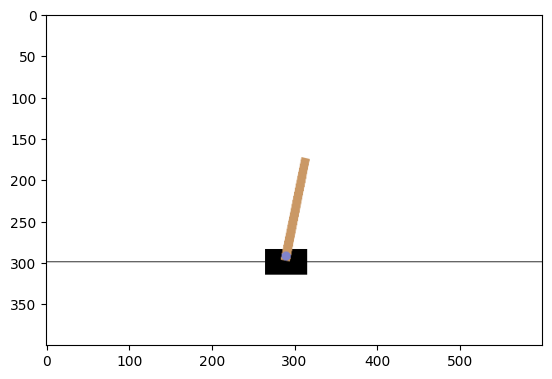

In [120]:
# DQNを動かす
episodes = 300
sync_interval = 20
reward_history = []
loss_history = []

env = gym.make("CartPole-v1", render_mode="rgb_array")
observation, info = env.reset(seed=42)

agent = DQNAgent()

# すべてのエピソードを保存
# env = RecordVideo(env, video_folder="./videos", episode_trigger=lambda e: True)

# 最後のエピソードのみを保存
env = RecordVideo(env, video_folder="./videos", episode_trigger=lambda e: e == episodes - 1)


for epi in range(episodes):
    obs, info = env.reset()
    obs = torch.from_numpy(obs)
    terminated = False
    truncated = False
    done = terminated or truncated
    total_reward = 0
    total_loss = 0
    img = plt.imshow(env.render()) # 最初のフレーム

    step = 1
    while not done:
        # 画像を更新
        img.set_data(env.render())
        display.display(plt.gcf())
        display.clear_output(wait=True)
        
        # print(f"obs: {obs}")
        # print(f"type(obs): {type(obs)}")
        
        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)
        
        # 学習
        loss = agent.update(
            obs,         # (B=32,4)
            action,      # (B=32,)
            reward,      # (B=32,)
            next_obs,    # (B=32,4)
            terminated,  # (B=32,)
            truncated,   # (B=32,)
            )

        # 状態遷移
        next_obs = torch.from_numpy(next_obs) # numpy -> tensor
        obs = next_obs

        # 総報酬
        total_reward += reward

        # 総損失
        total_loss += loss

        # Q学習ネットワークとターゲットネットワークの同期
        if epi % sync_interval == 0:
            agent.sync_qnet()

        

        # print(f"terminated: {terminated}")
        # print(f"type(terminated): {type(terminated)}")
        # print(f"truncated: {truncated}")
        # print(f"type(truncated): {type(truncated)}")
        if isinstance(terminated, np.ndarray) and isinstance(truncated, np.ndarray):
            done = terminated.any() or truncated.any()
        else:
            done = terminated or truncated
        step += 1

    reward_history.append(total_reward)
    loss_history.append(total_loss)

    print(f"Epi: {epi}, Step: {step}")
        
env.close()

rewards.shape: (300,)
losses.shape: (300,)


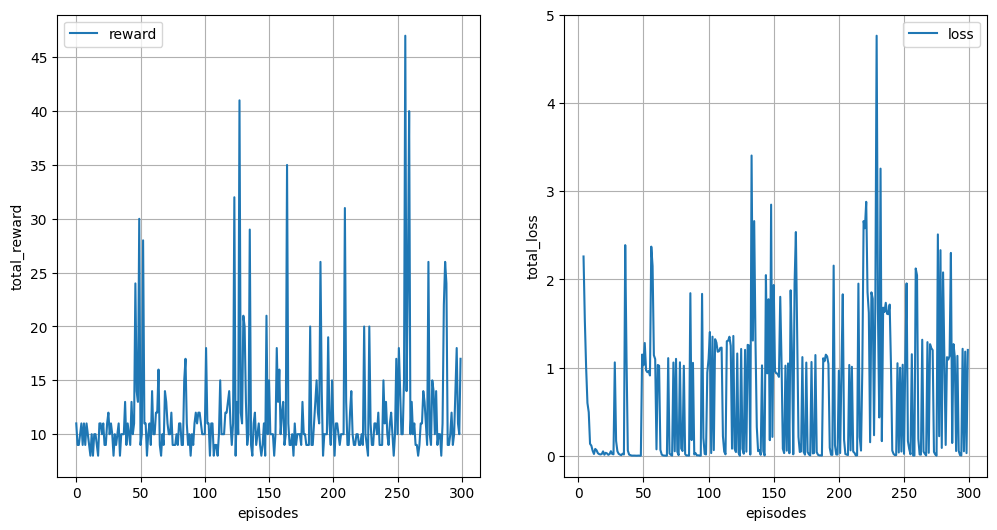

In [123]:
rewards = np.array(reward_history)
losses = np.array(loss_history)
print(f"rewards.shape: {rewards.shape}")
print(f"losses.shape: {losses.shape}")

fig, axes = plt.subplots(1,2, figsize=(12,6))


axes[0].plot(np.arange(rewards.shape[0]), rewards, label='reward')
axes[0].set_xlabel('episodes')
axes[0].set_ylabel('total_reward')
axes[0].grid()
axes[0].legend()

axes[1].plot(np.arange(losses.shape[0]), losses, label='loss')
axes[1].set_xlabel('episodes')
axes[1].set_ylabel('total_loss')
axes[1].grid()
axes[1].legend()

plt.show()